In [11]:
# Day 6 — Geometry and Drift Validation
# Task 1: Final Polygon Validation

import json
from pathlib import Path

from shapely.geometry import shape, Point
from pyproj import Geod

print("Imports successful.")

Imports successful.


In [17]:
# Load final slick polygon

POLYGON_PATH = Path("../../ml/day4_outputs/slick_geometry.geojson")

print("Looking for:", POLYGON_PATH.resolve())
print("File exists:", POLYGON_PATH.exists())

with open(POLYGON_PATH, "r", encoding="utf-8") as f:
    polygon_geojson = json.load(f)

print("Polygon file loaded.")
print("GeoJSON type:", polygon_geojson["type"])
print("Number of features:", len(polygon_geojson["features"]))

Looking for: D:\SpillTrace-SIH26\ml\day4_outputs\slick_geometry.geojson
File exists: True
Polygon file loaded.
GeoJSON type: FeatureCollection
Number of features: 75


In [18]:
# Inspect existing polygon feature metadata
# We are checking whether the final polygon can be identified
# without modifying the existing pipeline.

print("Total features:", len(polygon_geojson["features"]))
print()

for i, feature in enumerate(polygon_geojson["features"][:10]):
    print(f"Feature {i}:")
    print("  Geometry type:", feature.get("geometry", {}).get("type"))
    print("  Properties:", feature.get("properties", {}))
    print()

Total features: 75

Feature 0:
  Geometry type: Polygon
  Properties: {'slick_id': 1, 'centroid': [-121.828272, 47.68145], 'bounding_box': [-121.82946000000001, 47.68098, -121.82716, 47.68188], 'area_km2': 0.0195, 'perimeter_m': 712.45, 'orientation': 0.0, 'compactness': 0.4817, 'confidence': 0.3145}

Feature 1:
  Geometry type: Polygon
  Properties: {'slick_id': 2, 'centroid': [-121.923969, 47.681545], 'bounding_box': [-121.92526000000001, 47.68008, -121.92256, 47.68288], 'area_km2': 0.0584, 'perimeter_m': 1291.31, 'orientation': 27.9, 'compactness': 0.4399, 'confidence': 0.33}

Feature 2:
  Geometry type: Polygon
  Properties: {'slick_id': 3, 'centroid': [-121.862425, 47.680762], 'bounding_box': [-121.86476, 47.67828, -121.86026000000001, 47.68298], 'area_km2': 0.2016, 'perimeter_m': 2115.08, 'orientation': 90.0, 'compactness': 0.5664, 'confidence': 0.3724}

Feature 3:
  Geometry type: Polygon
  Properties: {'slick_id': 4, 'centroid': [-121.767846, 47.680997], 'bounding_box': [-121.7

In [19]:
# Inspect all slick polygons and their existing metadata

slick_summary = []

for feature in polygon_geojson["features"]:
    props = feature.get("properties", {})

    slick_summary.append({
        "slick_id": props.get("slick_id"),
        "centroid_lon": props.get("centroid", [None, None])[0],
        "centroid_lat": props.get("centroid", [None, None])[1],
        "area_km2": props.get("area_km2"),
        "perimeter_m": props.get("perimeter_m"),
        "confidence": props.get("confidence"),
    })

for row in slick_summary:
    print(
        f"slick_id={row['slick_id']:>2} | "
        f"centroid=({row['centroid_lon']}, {row['centroid_lat']}) | "
        f"area={row['area_km2']} km² | "
        f"perimeter={row['perimeter_m']} m | "
        f"confidence={row['confidence']}"
    )

slick_id= 1 | centroid=(-121.828272, 47.68145) | area=0.0195 km² | perimeter=712.45 m | confidence=0.3145
slick_id= 2 | centroid=(-121.923969, 47.681545) | area=0.0584 km² | perimeter=1291.31 m | confidence=0.33
slick_id= 3 | centroid=(-121.862425, 47.680762) | area=0.2016 km² | perimeter=2115.08 m | confidence=0.3724
slick_id= 4 | centroid=(-121.767846, 47.680997) | area=0.1657 km² | perimeter=2449.04 m | confidence=0.4026
slick_id= 5 | centroid=(-121.846784, 47.681074) | area=0.3827 km² | perimeter=2938.85 m | confidence=0.393
slick_id= 6 | centroid=(-122.129606, 47.680598) | area=0.9675 km² | perimeter=8081.83 m | confidence=0.4888
slick_id= 7 | centroid=(-121.847074, 47.67643) | area=0.026 km² | perimeter=868.3 m | confidence=0.3041
slick_id= 8 | centroid=(-121.801581, 47.66209) | area=0.1908 km² | perimeter=2716.21 m | confidence=0.3884
slick_id= 9 | centroid=(-121.847343, 47.660056) | area=0.0242 km² | perimeter=890.56 m | confidence=0.3091
slick_id=10 | centroid=(-122.062526, 47

In [20]:
# Inspect all polygon IDs and basic geometry properties

print("Total polygon features:", len(polygon_geojson["features"]))

for feature in polygon_geojson["features"]:
    props = feature.get("properties", {})
    geom = shape(feature["geometry"])

    print(
        f"slick_id={props.get('slick_id')} | "
        f"type={geom.geom_type} | "
        f"valid={geom.is_valid} | "
        f"empty={geom.is_empty}"
    )

Total polygon features: 75
slick_id=1 | type=Polygon | valid=True | empty=False
slick_id=2 | type=Polygon | valid=True | empty=False
slick_id=3 | type=Polygon | valid=True | empty=False
slick_id=4 | type=Polygon | valid=True | empty=False
slick_id=5 | type=Polygon | valid=True | empty=False
slick_id=6 | type=Polygon | valid=True | empty=False
slick_id=7 | type=Polygon | valid=True | empty=False
slick_id=8 | type=Polygon | valid=True | empty=False
slick_id=9 | type=Polygon | valid=True | empty=False
slick_id=10 | type=Polygon | valid=True | empty=False
slick_id=11 | type=Polygon | valid=True | empty=False
slick_id=12 | type=Polygon | valid=True | empty=False
slick_id=13 | type=Polygon | valid=True | empty=False
slick_id=14 | type=Polygon | valid=True | empty=False
slick_id=15 | type=Polygon | valid=True | empty=False
slick_id=16 | type=Polygon | valid=True | empty=False
slick_id=17 | type=Polygon | valid=True | empty=False
slick_id=18 | type=Polygon | valid=True | empty=False
slick_id=1

In [21]:
# Task 1 — Build unified slick geometry from all 75 features

from shapely.ops import unary_union

geometries = [
    shape(feature["geometry"])
    for feature in polygon_geojson["features"]
]

# Validate individual input geometries first
invalid_count = sum(not geom.is_valid for geom in geometries)
empty_count = sum(geom.is_empty for geom in geometries)

# Dissolve all 75 polygon features into one unified slick geometry
unified_slick = unary_union(geometries)

print("Input polygon count:", len(geometries))
print("Invalid input geometries:", invalid_count)
print("Empty input geometries:", empty_count)
print("Unified geometry type:", unified_slick.geom_type)
print("Unified geometry valid:", unified_slick.is_valid)
print("Unified geometry empty:", unified_slick.is_empty)

Input polygon count: 75
Invalid input geometries: 0
Empty input geometries: 0
Unified geometry type: MultiPolygon
Unified geometry valid: True
Unified geometry empty: False


In [22]:
# Task 1 — Centroid, geodesic area and geodesic perimeter

geod = Geod(ellps="WGS84")

# Centroid of the unified slick
slick_centroid = unified_slick.centroid

centroid_lon = slick_centroid.x
centroid_lat = slick_centroid.y

# Geodesic area and perimeter
area_m2, perimeter_m = geod.geometry_area_perimeter(unified_slick)

# Area can be signed depending on polygon ring orientation
area_m2 = abs(area_m2)

area_km2 = area_m2 / 1_000_000

# Check whether centroid lies within / on the unified geometry
centroid_inside = unified_slick.covers(slick_centroid)

print(f"Unified centroid longitude: {centroid_lon:.6f}")
print(f"Unified centroid latitude:  {centroid_lat:.6f}")
print(f"Centroid inside unified slick: {centroid_inside}")
print(f"Geodesic area: {area_m2:.2f} m²")
print(f"Geodesic area: {area_km2:.6f} km²")
print(f"Geodesic perimeter: {perimeter_m:.2f} m")
print(f"Area > 0: {area_m2 > 0}")
print(f"Perimeter > 0: {perimeter_m > 0}")

Unified centroid longitude: -122.001858
Unified centroid latitude:  47.464369
Centroid inside unified slick: False
Geodesic area: 21073372.98 m²
Geodesic area: 21.073373 km²
Geodesic perimeter: 229912.39 m
Area > 0: True
Perimeter > 0: True


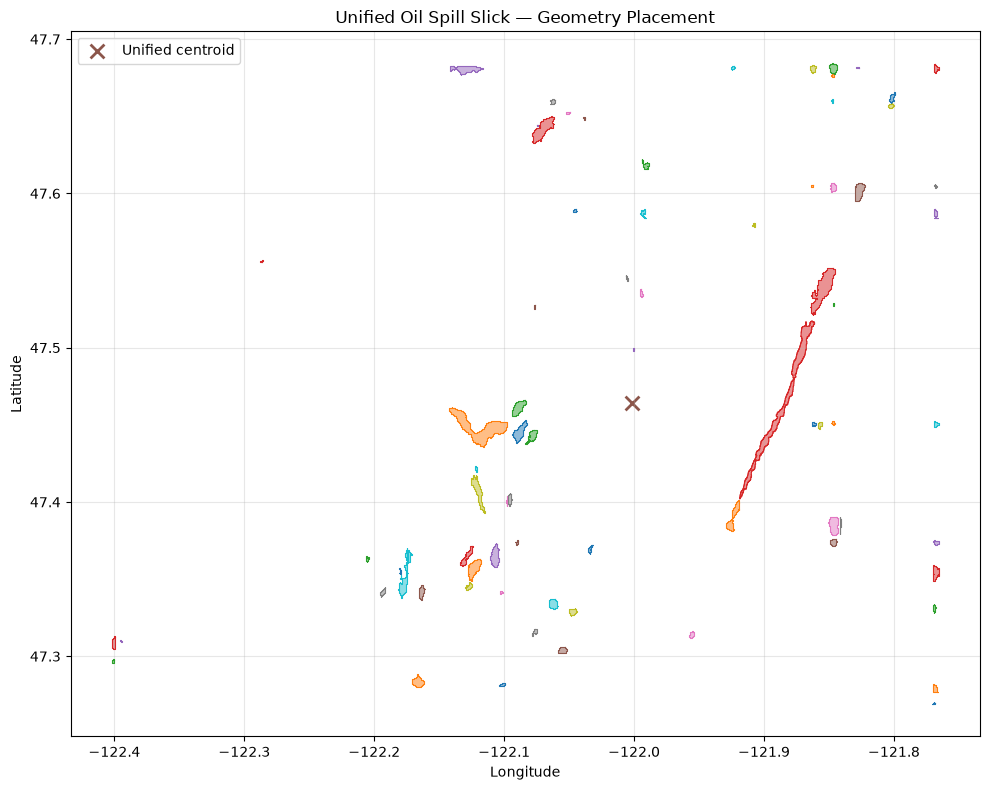

In [23]:
# Task 1 — Sensible map placement
# Visualize the unified slick geometry and its centroid.

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

# Plot unified slick
if unified_slick.geom_type == "MultiPolygon":
    for polygon in unified_slick.geoms:
        x, y = polygon.exterior.xy
        ax.fill(x, y, alpha=0.5)
        ax.plot(x, y, linewidth=0.8)
else:
    x, y = unified_slick.exterior.xy
    ax.fill(x, y, alpha=0.5)
    ax.plot(x, y, linewidth=0.8)

# Plot unified geometric centroid
ax.scatter(
    centroid_lon,
    centroid_lat,
    marker="x",
    s=100,
    linewidths=2,
    label="Unified centroid"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Unified Oil Spill Slick — Geometry Placement")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# Task 2.1 — Deterministic drift validation
# Validate direction handling and distance units.

import math

# Same parameters used by the Day 5 operational hindcast
WIND_SPEED_KNOTS = 15.0
WIND_DIR_FROM = 270.0
CURRENT_SPEED_KNOTS = 1.2
CURRENT_DIR_TO = 90.0

WIND_COEFF = 0.03
CURRENT_COEFF = 1.0
KNOTS_TO_METERS_PER_HOUR = 1852.0

# Convert wind FROM direction to TO direction
wind_to_dir = (WIND_DIR_FROM + 180.0) % 360.0

# Wind vector
wind_u = (
    WIND_SPEED_KNOTS
    * KNOTS_TO_METERS_PER_HOUR
    * WIND_COEFF
    * math.sin(math.radians(wind_to_dir))
)

wind_v = (
    WIND_SPEED_KNOTS
    * KNOTS_TO_METERS_PER_HOUR
    * WIND_COEFF
    * math.cos(math.radians(wind_to_dir))
)

# Current vector
curr_u = (
    CURRENT_SPEED_KNOTS
    * KNOTS_TO_METERS_PER_HOUR
    * CURRENT_COEFF
    * math.sin(math.radians(CURRENT_DIR_TO))
)

curr_v = (
    CURRENT_SPEED_KNOTS
    * KNOTS_TO_METERS_PER_HOUR
    * CURRENT_COEFF
    * math.cos(math.radians(CURRENT_DIR_TO))
)

# Combined forward vector
total_u = wind_u + curr_u
total_v = wind_v + curr_v

# Reverse vector for hindcast
hindcast_u = -total_u
hindcast_v = -total_v

hindcast_distance_m_per_hour = math.hypot(
    hindcast_u,
    hindcast_v
)

hindcast_bearing_deg = (
    math.degrees(
        math.atan2(hindcast_u, hindcast_v)
    ) + 360.0
) % 360.0

print("=== Direction and Unit Validation ===")
print(f"Wind FROM direction: {WIND_DIR_FROM:.1f}°")
print(f"Wind TO direction:   {wind_to_dir:.1f}°")
print()
print(f"Wind vector:   u={wind_u:.2f} m/h, v={wind_v:.2f} m/h")
print(f"Current vector: u={curr_u:.2f} m/h, v={curr_v:.2f} m/h")
print()
print(f"Combined forward vector: u={total_u:.2f}, v={total_v:.2f} m/h")
print(f"Reverse hindcast vector: u={hindcast_u:.2f}, v={hindcast_v:.2f} m/h")
print()
print(f"Hindcast distance: {hindcast_distance_m_per_hour:.2f} m/hour")
print(f"Hindcast bearing:  {hindcast_bearing_deg:.2f}°")

# Assertions
assert wind_to_dir == 90.0
assert abs(hindcast_distance_m_per_hour - math.hypot(hindcast_u, hindcast_v)) < 1e-9
assert 0.0 <= hindcast_bearing_deg < 360.0

print()
print("Direction test: PASS")
print("Unit/distance calculation test: PASS")

=== Direction and Unit Validation ===
Wind FROM direction: 270.0°
Wind TO direction:   90.0°

Wind vector:   u=833.40 m/h, v=0.00 m/h
Current vector: u=2222.40 m/h, v=0.00 m/h

Combined forward vector: u=3055.80, v=0.00 m/h
Reverse hindcast vector: u=-3055.80, v=-0.00 m/h

Hindcast distance: 3055.80 m/hour
Hindcast bearing:  270.00°

Direction test: PASS
Unit/distance calculation test: PASS


In [26]:
# Task 2.2 — Pure East/West zero-latitude-drift validation
#
# For this deterministic test, zero-latitude-drift means:
# the drift vector has zero north/south component (v = 0).
# We do NOT use a geodesic endpoint latitude as the assertion,
# because a geodesic east/west path on a curved Earth is not
# exactly a constant-latitude path.

import math

TEST_SPEED_MPS = 10.0

def drift_components(speed_mps, direction_deg):
    """Return east-west (u) and north-south (v) components."""
    u = speed_mps * math.sin(math.radians(direction_deg))
    v = speed_mps * math.cos(math.radians(direction_deg))
    return u, v

# Pure EAST
east_u, east_v = drift_components(TEST_SPEED_MPS, 90.0)

# Pure WEST
west_u, west_v = drift_components(TEST_SPEED_MPS, 270.0)

print("=== Pure East/West Zero-Latitude-Drift Test ===")
print()

print("EAST (90°):")
print(f"  u (east-west component): {east_u:.12f} m/s")
print(f"  v (north-south component): {east_v:.12f} m/s")

print()

print("WEST (270°):")
print(f"  u (east-west component): {west_u:.12f} m/s")
print(f"  v (north-south component): {west_v:.12f} m/s")

# Numerical tolerance for floating-point cosine/sine evaluation
VECTOR_TOLERANCE = 1e-12

east_zero_lat_drift = abs(east_v) < VECTOR_TOLERANCE
west_zero_lat_drift = abs(west_v) < VECTOR_TOLERANCE

print()
print(f"East zero north/south component: {east_zero_lat_drift}")
print(f"West zero north/south component: {west_zero_lat_drift}")

assert east_zero_lat_drift, "Pure eastward vector has a non-zero north/south component."
assert west_zero_lat_drift, "Pure westward vector has a non-zero north/south component."

print()
print("Pure east/west zero-latitude-drift test: PASS")

=== Pure East/West Zero-Latitude-Drift Test ===

EAST (90°):
  u (east-west component): 10.000000000000 m/s
  v (north-south component): 0.000000000000 m/s

WEST (270°):
  u (east-west component): -10.000000000000 m/s
  v (north-south component): -0.000000000000 m/s

East zero north/south component: True
West zero north/south component: True

Pure east/west zero-latitude-drift test: PASS


In [28]:
# Install missing dependency required by the existing Day 5 drift implementation

%pip install geopy


   ---------------------------------------- 0/2 [geographiclib]
   ---------------------------------------- 0/2 [geographiclib]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   ---------------------------------------- 2/2 [geopy]

Note: you may need to restart the kernel to use updated packages.


In [29]:
# Task 2.3 — Same-seed reproducibility

import sys
from pathlib import Path

# Locate the Day 5 ML directory from this notebook
PROJECT_ROOT = Path("../../").resolve()
ML_DIR = PROJECT_ROOT / "ml"

if str(ML_DIR) not in sys.path:
    sys.path.insert(0, str(ML_DIR))

from day5_drift import run_monte_carlo_simulation_scenario

# Identical parameters and identical random seed
params = {
    "test_name": "Day6 Reproducibility Test",
    "wind_mps": 7.7167,
    "wind_dir": 270.0,
    "curr_mps": 0.6173,
    "curr_dir": 90.0,
    "seed_val": 42,
}

result_1 = run_monte_carlo_simulation_scenario(**params)
result_2 = run_monte_carlo_simulation_scenario(**params)

metrics_1 = result_1["metrics"]
metrics_2 = result_2["metrics"]

print("=== Same-Seed Reproducibility Test ===")
print()

print("Run 1:")
print(f"  Predicted origin: "
      f"({metrics_1['predicted_origin_lon']:.6f}, "
      f"{metrics_1['predicted_origin_lat']:.6f})")
print(f"  Uncertainty radius: "
      f"{metrics_1['final_uncertainty_radius_m']:.2f} m")

print()

print("Run 2:")
print(f"  Predicted origin: "
      f"({metrics_2['predicted_origin_lon']:.6f}, "
      f"{metrics_2['predicted_origin_lat']:.6f})")
print(f"  Uncertainty radius: "
      f"{metrics_2['final_uncertainty_radius_m']:.2f} m")

# Compare deterministic result fields.
same_origin = (
    metrics_1["predicted_origin_lat"]
    == metrics_2["predicted_origin_lat"]
    and
    metrics_1["predicted_origin_lon"]
    == metrics_2["predicted_origin_lon"]
)

same_uncertainty = (
    metrics_1["final_uncertainty_radius_m"]
    == metrics_2["final_uncertainty_radius_m"]
)

reproducible = same_origin and same_uncertainty

print()
print(f"Same predicted origin: {same_origin}")
print(f"Same uncertainty radius: {same_uncertainty}")
print(f"Reproducibility: {reproducible}")

assert reproducible, "Same-seed Monte Carlo results are not reproducible."

print()
print("Same-seed reproducibility test: PASS")

=== Same-Seed Reproducibility Test ===

Run 1:
  Predicted origin: (70.709029, 19.495748)
  Uncertainty radius: 1191.87 m

Run 2:
  Predicted origin: (70.709029, 19.495748)
  Uncertainty radius: 1191.87 m

Same predicted origin: True
Same uncertainty radius: True
Reproducibility: True

Same-seed reproducibility test: PASS


In [31]:
# Task 3 — Load actual Day 5 sensitivity results

SENSITIVITY_PATH = Path("../../ml/day5_outputs/sensitivity_report.json")

print("Looking for:", SENSITIVITY_PATH.resolve())
print("File exists:", SENSITIVITY_PATH.exists())

with open(SENSITIVITY_PATH, "r", encoding="utf-8") as f:
    sensitivity_results = json.load(f)

print("Sensitivity report loaded.")
print("Number of runs:", len(sensitivity_results))

for run in sensitivity_results:
    print(
        f"{run['test_scenario']} | "
        f"seed={run['parameters']['random_seed']} | "
        f"uncertainty={run['metrics']['final_uncertainty_radius_m']:.2f} m"
    )

Looking for: D:\SpillTrace-SIH26\ml\day5_outputs\sensitivity_report.json
File exists: True
Sensitivity report loaded.
Number of runs: 5
Baseline Run | seed=42 | uncertainty=1191.87 m
Reproducibility Check (Same Seed) | seed=42 | uncertainty=1191.87 m
Sensitivity: High Wind (+20%) | seed=42 | uncertainty=1191.87 m
Sensitivity: High Current (+20%) | seed=42 | uncertainty=1191.88 m
Seed Variance (Seed 99) | seed=99 | uncertainty=1149.12 m


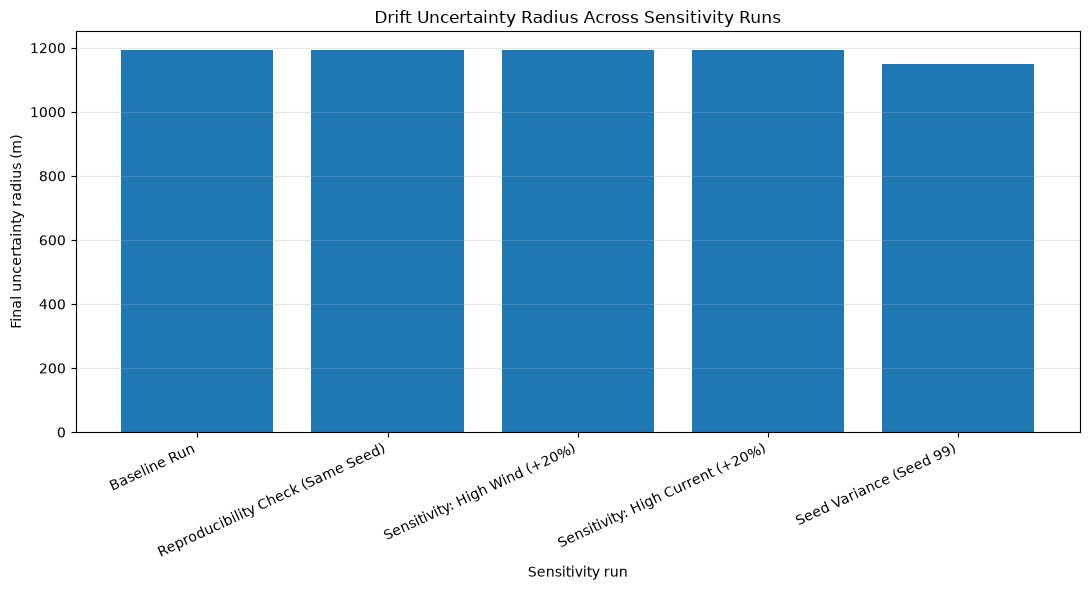

In [32]:
# Task 3 — Drift uncertainty radius chart
#
# This is an uncertainty-radius comparison, NOT a particle-spread plot.

import matplotlib.pyplot as plt

scenario_names = []
uncertainty_radii_m = []

for run in sensitivity_results:
    scenario_names.append(run["test_scenario"])
    uncertainty_radii_m.append(
        run["metrics"]["final_uncertainty_radius_m"]
    )

plt.figure(figsize=(11, 6))

plt.bar(
    range(len(scenario_names)),
    uncertainty_radii_m
)

plt.xticks(
    range(len(scenario_names)),
    scenario_names,
    rotation=25,
    ha="right"
)

plt.ylabel("Final uncertainty radius (m)")
plt.xlabel("Sensitivity run")
plt.title("Drift Uncertainty Radius Across Sensitivity Runs")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
# Task 4 — Review data-mode label for every drift run

print("=== Day 6 — Data-Mode Review ===")
print()

for i, run in enumerate(sensitivity_results, start=1):
    print(f"Run {i}")
    print(f"Scenario: {run.get('test_scenario', 'UNAVAILABLE')}")

    # Show the actual data-mode field if present
    data_mode = run.get("data_mode", None)

    # Also inspect synthetic-data metadata when available
    synthetic_data = run.get("synthetic_data", None)
    synthetic_scope = run.get("synthetic_data_scope", None)

    print(f"Data mode: {data_mode}")
    print(f"Synthetic data: {synthetic_data}")
    print(f"Synthetic data scope: {synthetic_scope}")

    print("-" * 60)

=== Day 6 — Data-Mode Review ===

Run 1
Scenario: Baseline Run
Data mode: None
Synthetic data: None
Synthetic data scope: None
------------------------------------------------------------
Run 2
Scenario: Reproducibility Check (Same Seed)
Data mode: None
Synthetic data: None
Synthetic data scope: None
------------------------------------------------------------
Run 3
Scenario: Sensitivity: High Wind (+20%)
Data mode: None
Synthetic data: None
Synthetic data scope: None
------------------------------------------------------------
Run 4
Scenario: Sensitivity: High Current (+20%)
Data mode: None
Synthetic data: None
Synthetic data scope: None
------------------------------------------------------------
Run 5
Scenario: Seed Variance (Seed 99)
Data mode: None
Synthetic data: None
Synthetic data scope: None
------------------------------------------------------------


# Day 6 — Final Validation Status

## Geometry Validation

- 75 polygon features were validated as one unified slick.
- Invalid input geometries: 0.
- Empty input geometries: 0.
- Unified geometry: MultiPolygon.
- Unified geometry is valid and non-empty.
- Geodesic area: 21.073373 km².
- Geodesic perimeter: 229912.39 m.
- Unified geometric centroid: (-122.001858, 47.464369).
- Centroid-inside check: FALSE.
- Spatial placement was visually inspected using longitude/latitude coordinates.

## Deterministic Drift Validation

- Direction convention: PASS.
- Distance/unit calculation: PASS.
- Pure east/west zero north-south drift-component test: PASS.
- Same-seed reproducibility: PASS.

## Uncertainty Validation

- Actual uncertainty-radius results were available for all five sensitivity runs.
- Uncertainty-radius sensitivity chart was created.
- Individual Monte Carlo particle coordinates were not persisted in the supplied output.
- Therefore, no particle-spread plot was fabricated.

## Data-Mode Review

- Operational hindcast: `analyst-parameter-driven`.
- Controlled validation: `controlled_simulation`.
- Sensitivity report runs: explicit run-level `data_mode` field is MISSING.
- Baseline, Reproducibility, High Wind, High Current and Seed 99 therefore remain `MISSING_EXPLICIT_RUN_LEVEL_LABEL`.
- No missing data-mode field was fabricated in this notebook.

## Day 6 Overall

Day 6 validation work is complete. Observed issues are retained explicitly:
1. Unified geometric centroid is not covered by the MultiPolygon.
2. Sensitivity runs lack explicit run-level `data_mode` metadata.
3. Individual particle coordinates are unavailable, so only the legitimate uncertainty-radius chart is provided.